<a href="https://colab.research.google.com/github/Helothlad/Monte-Carlo-simulations/blob/main/BettingSimulations.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [41]:
import random
import matplotlib
import matplotlib.pyplot as plt
import time
import csv
#%matplotlib notebook

In [4]:
lower_bust = 31.235
higher_profit = 63.208

sampleSize = 1000
startingFunds = 100000
wagerSize = 10
wagerCount = 1000


In [5]:
def rollDice():
  roll = random.randint(1,100)

  if roll == 100:
    return False
  elif roll <= 50:
    return False
  elif 100 > roll > 50:
    return True


In [6]:
def rollDice50():
  roll = random.randint(1,100)

  if roll <= 50:
    return False
  elif roll >= 51:
    return True

In [7]:
def dAlembert(funds, initial_wager, wager_count):
  global da_busts
  global da_profits
  global Ret
  value = funds
  wager = initial_wager

  currentWager = 1
  previousWager = 'win'
  previousWagerAmount = initial_wager

  while currentWager <= wager_count:
    if previousWager == 'win':
      if wager == initial_wager:
        pass
      else:
        wager -= initial_wager

      if rollDice50():
        value += wager
        previousWagerAmount = wager
      else:
        value -= wager
        previousWager = 'loss'
        previousWagerAmount = wager
        if value <= 0:
          da_busts += 1
          break
    elif previousWager == 'loss':
      wager = previousWagerAmount + initial_wager
      if (value - wager) <= 0:
        wager = value

      if rollDice50():
        value += wager
        previousWagerAmount = wager
        previousWager = 'win'
      else:
        value -= wager
        previousWagerAmount = wager

        if value <= 0:
          da_busts += 1
          break

    currentWager += 1

  if value > funds:
    da_profits += 1
  Ret += value

In [8]:
def simple_bettor(funds, initial_wager, wager_count, color):
  value = funds
  wager = initial_wager
  global simple_busts
  global simple_profits
  wX = []
  vY = []

  currentWager = 0

  while currentWager <= wager_count:
    if rollDice():
      value += wager
      wX.append(currentWager)
      vY.append(value)
    else:
      value -= wager
      wX.append(currentWager)
      vY.append(value)
    currentWager += 1

  if value <= 0:
    value = 0
    simple_busts += 1

  plt.plot(wX, vY, color)
  if value > funds:
    value = 0
    simple_profits+=1

In [9]:
def doubler_better(funds, initial_wager, wager_count, color):
  value = funds
  wager = initial_wager

  global doubler_busts
  global doubler_profits
  wX = []
  vY = []

  currentWager = 1

  previousWager = 'win'
  previousWagerAmount = initial_wager

  while currentWager <= wager_count:
    if previousWager == 'win':
      if rollDice():
        value += wager
        wX.append(currentWager)
        vY.append(value)
      else:
        value -= wager
        previousWager = 'loss'
        previousWagerAmount = wager
        wX.append(currentWager)
        vY.append(value)
        if value <= 0:
          doubler_busts += 1
          break
    elif previousWager == 'loss':
      if rollDice():
        wager = previousWagerAmount * 2

        if (value - wager) < 0:
          wager = value
        value += wager
        wager = initial_wager
        previousWager = 'win'
        wX.append(currentWager)
        vY.append(value)
      else:
        wager = previousWagerAmount * 2
        if (value - wager) < 0:
          wager = value
        value -= wager
        previousWagerAmount = wager
        wX.append(currentWager)
        vY.append(value)
        if value <= 0:
          doubler_busts += 1
          break
        previousWager = 'loss'



    currentWager += 1
  plt.plot(wX,vY, color)
  if value > funds:
    doubler_profits += 1

In [10]:
def multiple_bettor(funds, initial_wager, wager_count):
  global multiple_busts
  global multiple_profits
  global random_multiple
  value = funds
  wager = initial_wager

  currentWager = 1
  previousWager = 'win'

  previousWagerAmount = initial_wager

  while currentWager <= wager_count:
    if previousWager == 'win':
      if rollDice():
        value += wager
      else:
        value -= wager
        previousWager = 'loss'
        previousWagerAmount = wager
        if value <= 0:
          multiple_busts += 1
          break
    elif previousWager == 'loss':
      if rollDice():
        wager = previousWagerAmount * random_multiple

        if (value - wager) < 0:
          wager = value
        value += wager
        wager = initial_wager
        previousWager = 'win'
      else:
        wager = previousWagerAmount * random_multiple
        if (value - wager) < 0:
          wager = value
        value -= wager
        previousWagerAmount = wager
        if value <= 0:
          multiple_busts += 1
          break
        previousWager = 'loss'

    currentWager += 1
  if value > funds:
    multiple_profits += 1

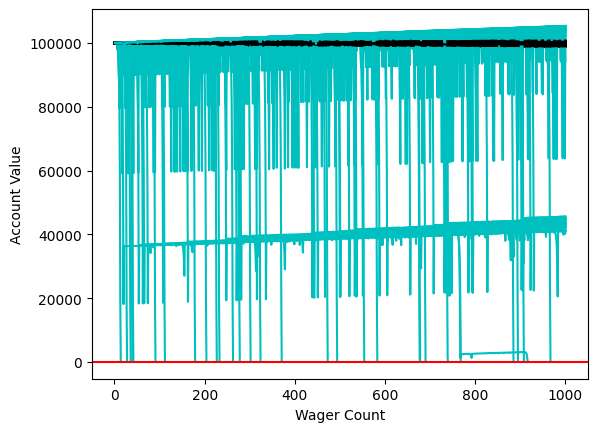

Simple better bust chance:  0.0
Simple profits chances:  27.1
Doubler better bust chance:  3.0
Doubler profits chances:  93.10000000000001


In [11]:
x = 0
simple_busts = 0.0
simple_profits = 0.0
doubler_busts = 0.0
doubler_profits = 0.0
while x < sampleSize:
  simple_bettor(startingFunds, wagerSize, wagerCount, 'k')
  doubler_better(startingFunds, wagerSize, wagerCount, 'c')
  x += 1

plt.axhline(0, color='r')
plt.ylabel('Account Value')
plt.xlabel('Wager Count')
plt.show()
print('Simple better bust chance: ', (simple_busts/sampleSize) * 100.00)
print('Simple profits chances: ', (simple_profits/sampleSize) * 100.00)


print('Doubler better bust chance: ', (doubler_busts/sampleSize) * 100.00)
print('Doubler profits chances: ', (doubler_profits/sampleSize) * 100.00)

In [12]:
while True:
  multiple_busts = 0.0
  multiple_profits = 0.0

  multipleSampleSize = 100000
  currentSample = 1

  random_multiple = random.uniform(0.1, 3.0)
  while currentSample <= multipleSampleSize:
    multiple_bettor(startingFunds, wagerSize, wagerCount)
    currentSample += 1

  if ((multiple_busts/multipleSampleSize) * 100.00 < lower_bust) and ((multiple_profits/multipleSampleSize)*100.00 > higher_profit):
    print('################################')
    print('Found a winner the multiple was: ', random_multiple)
    print('Lower bust to bead', lower_bust)
    print('Higher profit rate to beat: ', higher_profit)
    print('Bust rate: ', (multiple_busts/multipleSampleSize)*100.00)
    print('Profit rate: ', (multiple_profits/multipleSampleSize)*100.00)
    print('################################')

KeyboardInterrupt: 

In [ ]:
da_busts = 0.0
da_profits = 0.0
Ret = 0.0
daSampleSize = 100000

counter = 1

while counter <= daSampleSize:
  dAlembert(startingFunds, wagerSize, wagerCount)
  counter += 1
print('Total invested: ', daSampleSize*startingFunds)
print('Total Return: ', Ret)
print('ROI', Ret - (daSampleSize*startingFunds))
print('Bust Rate: ', (da_busts/daSampleSize)*100.00)
print('Profit Rate: ', (da_profits/daSampleSize)*100.00)

In [16]:
sampleSize = 1000
startingFunds = 10000

while True:

  wagerSize = random.uniform(1.0,1000.00)
  wagerCount = random.uniform(10.0,10000)

  Ret = 0.0
  da_profits = 0.0
  da_busts = 0.0
  daSampleSize = 10000

  counter = 1

  while counter <= daSampleSize:
    dAlembert(startingFunds, wagerSize, wagerCount)
    counter+=1

  ROI = Ret - (daSampleSize*startingFunds)
  totalInvested = daSampleSize*startingFunds

  percentROI = (ROI/totalInvested)*100.00

  wagerSizePercent = (wagerSize/startingFunds)*100.00
  if percentROI > 1:
    print('______________________________________')
    print('Total invested: ', daSampleSize*startingFunds)
    print('Total Return: ', Ret)
    print('ROI', Ret - (daSampleSize*startingFunds))
    print('Bust Rate: ', (da_busts/daSampleSize)*100.00)
    print('Percent ROI: ', percentROI)
    print('Profit Rate: ', (da_profits/daSampleSize)*100.00)
    print('Wager size: ', wagerSize)
    print('Wager Count: ',wagerCount)
    print('Wager size percentage: ',wagerSizePercent)
    saveFile = open('monteCarloLiberal.csv','a')
    saveLine = '\n' + str(percentROI) + ', ' + str(wagerSizePercent) + ', ' + str(wagerCount) + ',g'
    saveFile.write(saveLine)
    saveFile.close()
  elif percentROI < -1:
    print('______________________________________')
    print('Total invested: ', daSampleSize*startingFunds)
    print('Total Return: ', Ret)
    print('ROI', Ret - (daSampleSize*startingFunds))
    print('Bust Rate: ', (da_busts/daSampleSize)*100.00)
    print('Percent ROI: ', percentROI)
    print('Profit Rate: ', (da_profits/daSampleSize)*100.00)
    print('Wager size: ', wagerSize)
    print('Wager Count: ',wagerCount)
    print('Wager size percentage: ',wagerSizePercent)
    saveFile = open('monteCarloLiberal.csv','a')
    saveLine = '\n' + str(percentROI) + ', ' + str(wagerSizePercent) + ', ' + str(wagerCount) + ',r'
    saveFile.write(saveLine)
    saveFile.close()



______________________________________
Total invested:  100000000
Total Return:  108791557.18202904
ROI 8791557.182029039
Bust Rate:  96.78999999999999
Percent ROI:  8.791557182029038
Profit Rate:  3.2099999999999995
Wager size:  368.57727135574606
Wager Count:  2997.3834548547024
Wager size percentage:  3.6857727135574607
______________________________________
Total invested:  100000000
Total Return:  93682309.9491207
ROI -6317690.0508793
Bust Rate:  99.13
Percent ROI:  -6.317690050879301
Profit Rate:  0.8699999999999999
Wager size:  630.9446755354861
Wager Count:  5496.864391290785
Wager size percentage:  6.309446755354861
______________________________________
Total invested:  100000000
Total Return:  91176771.50456847
ROI -8823228.495431527
Bust Rate:  99.32
Percent ROI:  -8.823228495431527
Profit Rate:  0.6799999999999999
Wager size:  544.4337872487313
Wager Count:  6749.979673368464
Wager size percentage:  5.444337872487313
______________________________________
Total invested:  

KeyboardInterrupt: 